In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('retail_dataset.csv')

In [4]:
df.head()

,Transaction ID,Customer ID,Product Category,Quantity,Price,Date,Region
0,T001,C015,Books,7.0,167.0,02-02-2023,North
1,T002,C004,Toys,4.0,374.0,17-02-2023,South
2,T003,C033,Furniture,8.0,1059.0,17-05-2024,South
3,T004,C047,Groceries,5.0,304.0,11-02-2024,South
4,T005,C022,Books,7.0,282.0,27-07-2024,West


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    100 non-null    str    
 1   Customer ID       100 non-null    str    
 2   Product Category  100 non-null    str    
 3   Quantity          98 non-null     float64
 4   Price             95 non-null     float64
 5   Date              100 non-null    str    
 6   Region            100 non-null    str    
dtypes: float64(2), str(5)
memory usage: 5.6 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Product Category    0
Quantity            2
Price               5
Date                0
Region              0
dtype: int64

In [8]:
df[df['Quantity'].isna()]

,Transaction ID,Customer ID,Product Category,Quantity,Price,Date,Region
20,T021,C043,Books,NaN,516.0,07-07-2024,East
41,T042,C018,Toys,NaN,217.0,10-07-2024,North


In [9]:
df[df['Price'].isna()]

,Transaction ID,Customer ID,Product Category,Quantity,Price,Date,Region
10,T011,C003,Electronics,4.0,NaN,04-09-2024,East
17,T018,C039,Toys,8.0,NaN,28-01-2024,North
40,T041,C041,Toys,9.0,NaN,12-11-2024,South
54,T055,C041,Electronics,8.0,NaN,09-07-2023,North
87,T088,C050,Furniture,1.0,NaN,23-04-2023,West


In [10]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [11]:
df['Price'] = df['Price'].fillna(
    df.groupby('Product Category')['Price'].transform('median')
)

In [13]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [14]:
df['Revenue']=df['Price']*df['Quantity']

In [16]:
Total_Revenue=sum(df['Revenue'])

In [17]:
print(Total_Revenue)

492782.0


In [56]:
revenue_by_category =df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False)

In [57]:
revenue_by_category

Product Category
Furniture      130945.0
Electronics     93750.0
Clothing        89086.0
Toys            59354.0
Sports          44229.0
Books           29877.0
Beauty          28691.0
Groceries       16850.0
Name: Revenue, dtype: float64

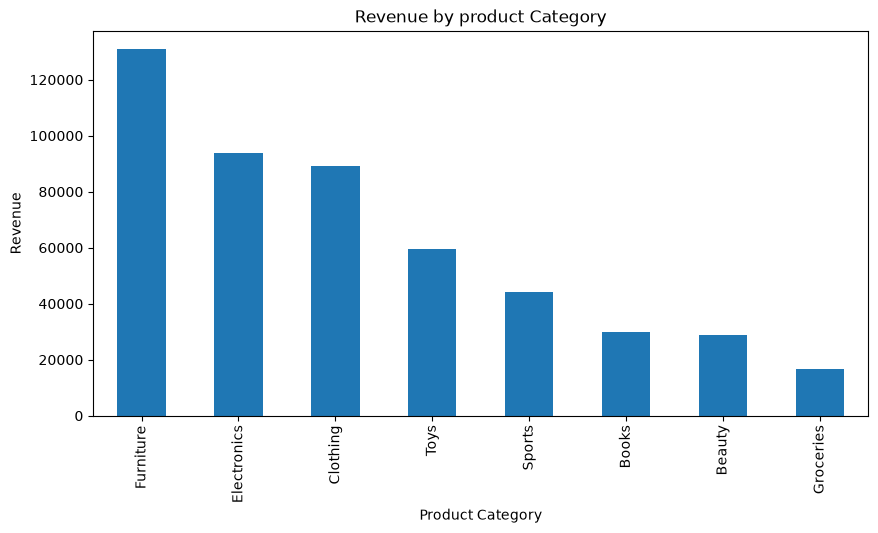

In [58]:
revenue_by_category.plot(kind='bar', figsize=(10, 5))
plt.title('Revenue by product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.show()

In [47]:
revenue_by_Region = df.groupby('Region')['Revenue'].sum()

In [48]:
revenue_by_Region

Region
East     135645.0
North    169434.5
South    105224.5
West      82478.0
Name: Revenue, dtype: float64

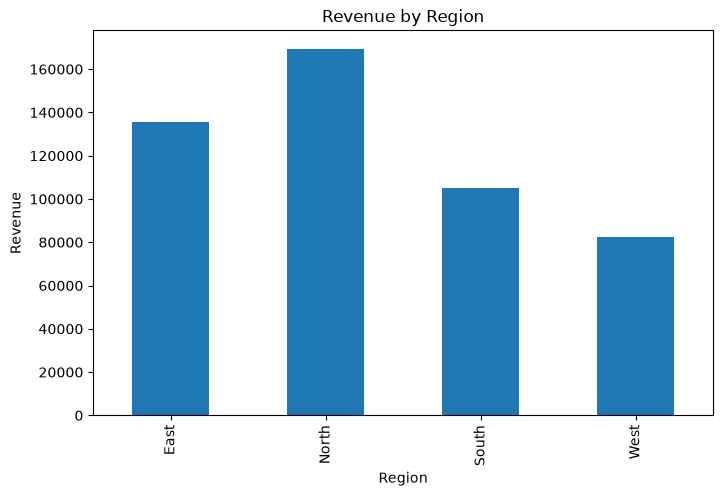

In [49]:
revenue_by_Region.plot(kind='bar', figsize=(8, 5))
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

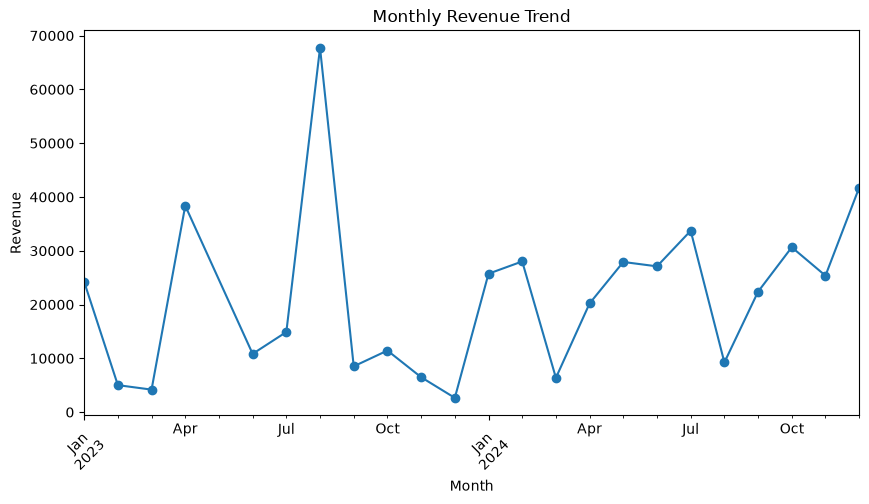

In [73]:
monthly_revenue = df.groupby(
    df['Date'].dt.to_period('M')
)['Revenue'].sum()

monthly_revenue.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

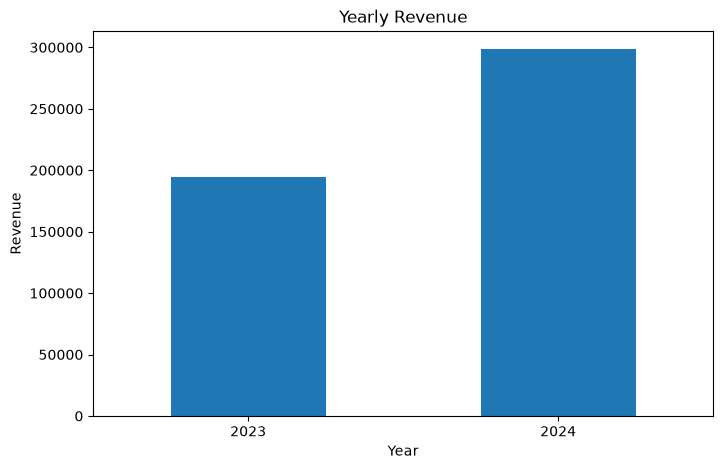

In [74]:
df['Year'] = df['Date'].dt.year
yearly_revenue = df.groupby('Year')['Revenue'].sum()

yearly_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Yearly Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

In [75]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
top_5_customers = customer_revenue.head(5)

In [76]:
top_5_customers 

Customer ID
C018    40674.5
C022    37256.0
C036    29010.0
C010    24181.0
C043    20626.0
Name: Revenue, dtype: float64

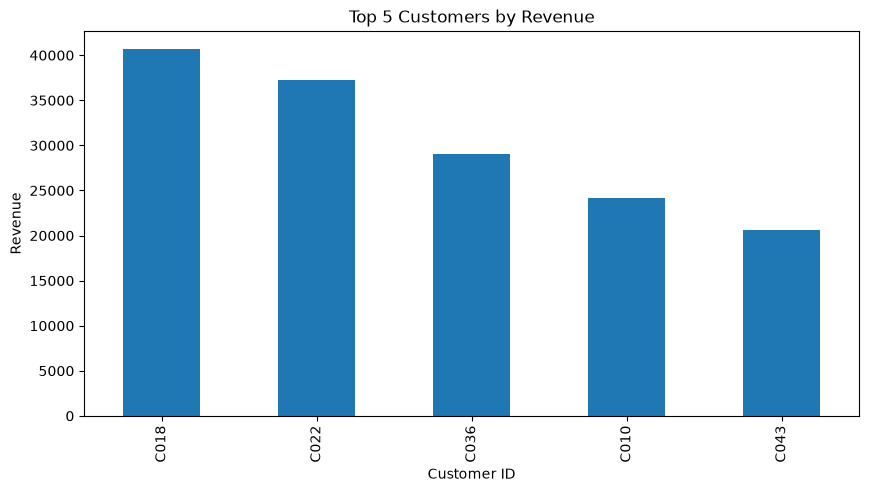

In [77]:
top_5_customers.plot(kind='bar', figsize=(10, 5))
plt.title('Top 5 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()